# Modeling

In [55]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

## Data exploration

In [69]:
reviews10 = gpd.read_file("data/reviews_demog10.gpkg")
reviews20 = gpd.read_file("data/reviews_demog20.gpkg")

In [70]:
reviews10.columns

Index(['GentYN', 'TRACTCE10', 'GEO_ID', 'index_right', 'business_id', 'name',
       'address', 'city', 'state', 'postal_code_x', 'latitude', 'longitude',
       'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours',
       'LISTNAME', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'brewery', 'tot_pop', 'prop_black', 'prop_asian',
       'prop_hispanic_or_latino', 'prop_white_only', 'med_prop_val', 'med_inc',
       'total_25_plus', 'pct_bachelor_or_higher', 'pct_bachelor_lower',
       'geometry'],
      dtype='object')

In [71]:
print(np.sum(reviews10.isna()))

GentYN                        0
TRACTCE10                     0
GEO_ID                        0
index_right                 138
business_id                 138
name                        138
address                     138
city                        138
state                       138
postal_code_x               138
latitude                    138
longitude                   138
stars                       138
review_count                138
is_open                     138
attributes                  145
categories                  138
hours                      3701
LISTNAME                    138
review_id                   138
user_id                     138
useful                      138
funny                       138
cool                        138
text                        138
date                        138
brewery                     138
tot_pop                      62
prop_black                   62
prop_asian                   62
prop_hispanic_or_latino      62
prop_whi

/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [72]:
reviews10.head()

,GentYN,TRACTCE10,GEO_ID,index_right,business_id,name,address,city,state,postal_code_x,...,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower,geometry
0,0,000100,42101000100,125305.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
1,0,000100,42101000100,125309.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
2,0,000100,42101000100,125278.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
3,0,000100,42101000100,125276.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
4,0,000100,42101000100,125275.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."


In [107]:
tract_agg10 = reviews10.groupby("GEO_ID").agg(
    sum_brew_reviews = ("brewery", "sum"),
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    tot_pop = ("tot_pop", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first"),
    geometry = ("geometry", "first")
)

tract_agg10 = gpd.GeoDataFrame(tract_agg10)
tract_agg10.head()



,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,tot_pop,pct_bachelor_or_higher,gentrified,geometry
GEO_ID,,,,,,,,,,,
42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,3478.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,2937.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372..."
42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,3169.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909..."
42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,2125.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086..."
42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,3142.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360..."


In [108]:
tract_agg20 = reviews20.groupby("GEO_ID").agg(
    sum_brew_reviews = ("brewery", "sum"),
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    tot_pop = ("tot_pop", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first"),
    geometry = ("geometry", "first")
)

tract_agg20 = gpd.GeoDataFrame(tract_agg20)
tract_agg20.head()

,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,tot_pop,pct_bachelor_or_higher,gentrified,geometry
GEO_ID,,,,,,,,,,,
42101000101,189.0,0.064926,0.054959,0.101331,0.055818,93462.0,104458.0,2329,91.627635,0,"POLYGON ((2696727.529 235346.292, 2696698.358 ..."
42101000102,1.0,0.004049,0.050698,0.100826,0.059242,98400.0,104236.0,3511,81.796783,0,"POLYGON ((2696854.461 237342.42, 2696826.709 2..."
42101000200,0.0,0.000000,0.084942,0.634096,0.037125,190300.0,83854.0,3367,50.237530,0,"POLYGON ((2693678.98 237210.532, 2693630.886 2..."
42101000300,83.0,0.152294,0.080427,0.158631,0.061986,75611.0,84843.0,4501,82.147743,0,"POLYGON ((2688851.053 238782.014, 2688858.091 ..."
42101000401,0.0,0.000000,0.089657,0.276977,0.053474,145592.0,73438.0,3123,81.802351,0,"POLYGON ((2688653.351 236208.441, 2688775.578 ..."


In [109]:
print(tract_agg10.shape[0])
print(tract_agg20.shape[0])

384
352


In [110]:
print(tract_agg10.crs)
print(tract_agg20.crs)

None
None


In [111]:
tract_agg10 = tract_agg10.set_crs(reviews10.crs)
tract_agg20 = tract_agg20.set_crs(reviews20.crs)

(array([311.,  15.,   5.,   7.,   1.,   4.,   2.,   1.,   1.,   0.,   2.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

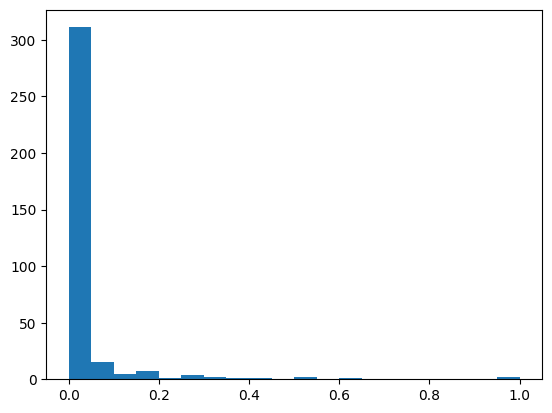

In [112]:
plt.hist(tract_agg20["mean_brew_reviews"], bins=20)

## Simple logistic regression models

In [113]:
mod_pre_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg10).fit()

mod_pre_1.summary()

Optimization terminated successfully.
         Current function value: 0.357628
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  233
Model:                          Logit   Df Residuals:                      225
Method:                           MLE   Df Model:                            7
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.08801
Time:                        14:52:07   Log-Likelihood:                -83.327
converged:                       True   LL-Null:                       -91.368
Covariance Type:            nonrobust   LLR p-value:                   0.02438
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.7906      1.107      0.714      0.475      -1.379       2.961
mean_brew_reviews           4.2704      2.011      2.123      0.034       0.329       8.212
prop_black                 -1.3783      0.897     -1.536      0.124      -3.137       0.380
prop_asian                  0.9848      1.038      0.949      0.343      -1.050       3.019
prop_hispanic_or_latino    -1.8639      1.579     -1.181      0.238      -4.958       1.231
med_prop_val             -7.05e-06   4.37e-06     -1.615      0.106   -1.56e-05    1.51e-06
med_inc                 -3.976e-05   1.85e-05     -2.146      0.032   -7.61e-05   -3.45e-06
pct_bachelor_or_higher      0.0189      0.019      0.978      0.328      -0.019       0.057
===========================================================================================
"""

In [114]:
mod_post_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg20).fit()

mod_post_1.summary()

Optimization terminated successfully.
         Current function value: 0.335107
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  328
Model:                          Logit   Df Residuals:                      320
Method:                           MLE   Df Model:                            7
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.06546
Time:                        14:52:07   Log-Likelihood:                -109.92
converged:                       True   LL-Null:                       -117.61
Covariance Type:            nonrobust   LLR p-value:                   0.03121
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.9194      1.003     -2.912      0.004      -4.884      -0.954
mean_brew_reviews           1.8828      1.369      1.375      0.169      -0.800       4.566
prop_black                 -0.2364      0.924     -0.256      0.798      -2.048       1.575
prop_asian                  1.4282      2.244      0.637      0.524      -2.969       5.826
prop_hispanic_or_latino    -0.7435      1.873     -0.397      0.691      -4.414       2.927
med_prop_val            -3.233e-06   3.73e-06     -0.867      0.386   -1.05e-05    4.07e-06
med_inc                  6.591e-06   9.29e-06      0.710      0.478   -1.16e-05    2.48e-05
pct_bachelor_or_higher      0.0145      0.013      1.108      0.268      -0.011       0.040
===========================================================================================
"""

In [115]:
tract_agg10['sum_brew_reviews']

GEO_ID
42101000100    101.0
42101000200      0.0
42101000300     21.0
42101000401      0.0
42101000402      0.0
               ...  
42101980600      0.0
42101980700      0.0
42101980800      0.0
42101980900      0.0
42101989100      0.0
Name: sum_brew_reviews, Length: 384, dtype: float64

## Doing it by slope over time

In [116]:
reviews10['date'] = pd.to_datetime(reviews10['date'])
reviews10['week_enum'] = reviews10['date'].dt.isocalendar().year * 52 + reviews10['date'].dt.isocalendar().week

reviews20['date'] = pd.to_datetime(reviews20['date'])
reviews20['week_enum'] = reviews20['date'].dt.isocalendar().year * 52 + reviews20['date'].dt.isocalendar().week


# aggregate to census tract x month level
# get total reviews and brewery reviews per tract per month
tract_month10 = (reviews10.groupby(['GEO_ID', 'week_enum'])
              .agg(total_reviews=('brewery', 'count'),
                   brewery_reviews=('brewery', 'sum'))
              .reset_index())

tract_month20 = (reviews20.groupby(['GEO_ID', 'week_enum'])
              .agg(total_reviews=('brewery', 'count'),
                   brewery_reviews=('brewery', 'sum'))
              .reset_index())

# calculate proportion of brewery reviews
tract_month10['prop_brewery'] = tract_month10['brewery_reviews'] / tract_month10['total_reviews']
tract_month20['prop_brewery'] = tract_month20['brewery_reviews'] / tract_month20['total_reviews']

# OLS for each tract, extract slope (or 0 if less than 2 brewery reviews)
def get_slope(group):
    if group['brewery_reviews'].sum() == 0:
        return 0.0

    if len(group) < 2:
        return 0.0
    try:
        model = smf.ols('prop_brewery ~ week_enum', data=group).fit()
        return model.params['week_enum']
    except Exception:
        return 0.0

slopes10 = (tract_month10.groupby('GEO_ID')
          .apply(get_slope)
          .reset_index()
          .rename(columns={0: 'brewery_prop_slope'}))
slopes20 = (tract_month20.groupby('GEO_ID')
          .apply(get_slope)
          .reset_index()
          .rename(columns={0: 'brewery_prop_slope'}))


tract_agg10 = tract_agg10.merge(slopes10, on='GEO_ID', how='left')
tract_agg20 = tract_agg20.merge(slopes20, on='GEO_ID', how='left')

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_1594/3456085682.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)
/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_1594/3456085682.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)


(array([  1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   4., 231.,   1.,   1.,   2.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.,   0.,   1.]),
 array([-4.63531236e-03, -4.36332110e-03, -4.09132985e-03, -3.81933859e-03,
        -3.54734734e-03, -3.27535608e-03, -3.00336483e-03, -2.73137357e-03,
        -2.45938232e-03, -2.18739106e-03, -1.91539981e-03, -1.64340855e-03,
        -1.37141730e-03, -1.09942604e-03, -8.27434788e-04, -5.55443533e-04,
        -2.83452278e-04, -1.14610230e-05,  2.60530232e-04,  5.32521487e-04,
         8.04512742e-04,  1.07650400e-03,  1.34849525e-03,  1.62048651e-03,
         1.89247776e-03,  2.16446902e-03,  2.43646027e-03,  2.70845153e-03,
         2.98044278e-03,  3.25243404e-03,  3.52442529e-03]),
 <BarContainer object of 30 artists>)

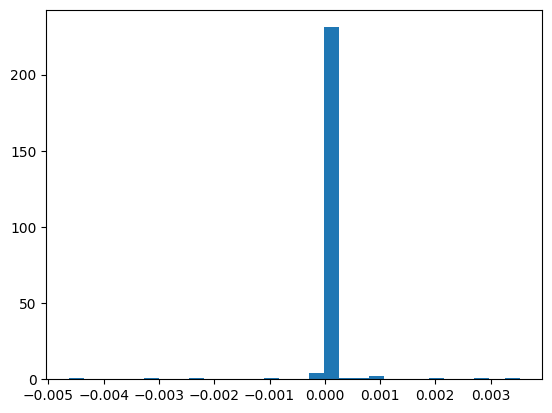

In [117]:
plt.hist(tract_agg10['brewery_prop_slope'], bins=30)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   1.,   5.,   0.,   9., 306.,
         16.,   4.,   1.,   2.,   4.,   0.,   2.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([-0.0047967 , -0.0043364 , -0.00387609, -0.00341578, -0.00295547,
        -0.00249516, -0.00203485, -0.00157454, -0.00111423, -0.00065392,
        -0.00019361,  0.0002667 ,  0.00072701,  0.00118732,  0.00164763,
         0.00210793,  0.00256824,  0.00302855,  0.00348886,  0.00394917,
         0.00440948,  0.00486979,  0.0053301 ,  0.00579041,  0.00625072,
         0.00671103,  0.00717134,  0.00763165,  0.00809196,  0.00855226,
         0.00901257]),
 <BarContainer object of 30 artists>)

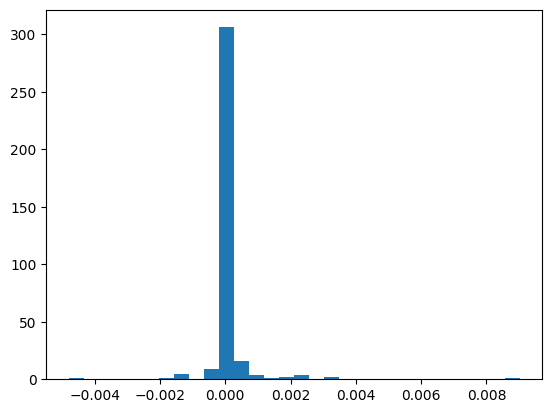

In [118]:
plt.hist(tract_agg20['brewery_prop_slope'], bins=30)

In [119]:
mod_pre_2 = smf.logit("gentrified ~  mean_brew_reviews + brewery_prop_slope + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg10).fit()

mod_pre_2.summary()

Optimization terminated successfully.
         Current function value: 0.357212
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  233
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                            8
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.08907
Time:                        14:52:08   Log-Likelihood:                -83.230
converged:                       True   LL-Null:                       -91.368
Covariance Type:            nonrobust   LLR p-value:                   0.03860
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.8136      1.110      0.733      0.463      -1.361       2.989
mean_brew_reviews           4.6353      2.204      2.103      0.035       0.316       8.954
brewery_prop_slope        133.8120    300.010      0.446      0.656    -454.197     721.821
prop_black                 -1.4008      0.900     -1.557      0.120      -3.165       0.363
prop_asian                  0.9446      1.046      0.903      0.367      -1.106       2.995
prop_hispanic_or_latino    -1.8892      1.583     -1.193      0.233      -4.992       1.213
med_prop_val            -7.059e-06   4.37e-06     -1.614      0.107   -1.56e-05    1.51e-06
med_inc                 -3.994e-05   1.85e-05     -2.157      0.031   -7.62e-05   -3.65e-06
pct_bachelor_or_higher      0.0187      0.019      0.969      0.332      -0.019       0.056
===========================================================================================
"""

In [120]:
X = mod_pre_2.model.exog
exog_names = mod_pre_2.model.exog_names

# Compute VIF for each feature (skip intercept at index 0)
vif_data = pd.DataFrame({
    'feature': exog_names[1:],
    'VIF': [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
})

print(vif_data.sort_values('VIF', ascending=False))

                   feature       VIF
5             med_prop_val  5.740779
7   pct_bachelor_or_higher  5.108882
6                  med_inc  2.348325
2               prop_black  1.964603
4  prop_hispanic_or_latino  1.454732
3               prop_asian  1.193978
0        mean_brew_reviews  1.126994
1       brewery_prop_slope  1.104229


In [121]:
mod_post_2 = smf.logit("gentrified ~  mean_brew_reviews + brewery_prop_slope + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg20).fit()

mod_post_2.summary()

Optimization terminated successfully.
         Current function value: 0.334428
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  328
Model:                          Logit   Df Residuals:                      319
Method:                           MLE   Df Model:                            8
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.06736
Time:                        14:52:08   Log-Likelihood:                -109.69
converged:                       True   LL-Null:                       -117.61
Covariance Type:            nonrobust   LLR p-value:                   0.04466
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.8721      1.004     -2.862      0.004      -4.839      -0.905
mean_brew_reviews           1.4519      1.554      0.934      0.350      -1.593       4.497
brewery_prop_slope        139.0311    204.500      0.680      0.497    -261.782     539.844
prop_black                 -0.2925      0.928     -0.315      0.753      -2.110       1.525
prop_asian                  1.2703      2.271      0.559      0.576      -3.181       5.722
prop_hispanic_or_latino    -0.7966      1.875     -0.425      0.671      -4.471       2.878
med_prop_val            -3.345e-06    3.8e-06     -0.881      0.378   -1.08e-05     4.1e-06
med_inc                  7.104e-06   9.35e-06      0.760      0.447   -1.12e-05    2.54e-05
pct_bachelor_or_higher      0.0135      0.013      1.024      0.306      -0.012       0.039
===========================================================================================
"""

In [122]:
X = mod_post_2.model.exog
exog_names = mod_post_2.model.exog_names

vif_data = pd.DataFrame({
    'feature': exog_names[1:],
    'VIF': [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
})

print(vif_data.sort_values('VIF', ascending=False))

                   feature       VIF
7   pct_bachelor_or_higher  4.178603
6                  med_inc  3.100871
2               prop_black  2.913154
4  prop_hispanic_or_latino  1.812034
5             med_prop_val  1.600800
3               prop_asian  1.477070
0        mean_brew_reviews  1.324405
1       brewery_prop_slope  1.242796


## GroupKFolds CV

In [123]:
# spatial join with neighborhoods
neighborhoods = gpd.read_file("data/philadelphia-neighborhoods.gpkg")

neighborhoods.crs == tract_agg10.crs

False

In [124]:
neighborhoods = neighborhoods.to_crs(tract_agg10.crs)

In [125]:
neighborhoods.head()

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719790.253 256235.935, 271981..."
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.53 289260.256, 2732819..."
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685268.357 279747.834, 268527..."
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.547 284400.913, 267851..."
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.553 263597.711, 268692..."


In [126]:
tract_agg10

,GEO_ID,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,tot_pop,pct_bachelor_or_higher,gentrified,geometry,brewery_prop_slope
0,42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,3478.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971...",0.000246
1,42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,2937.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372...",0.000000
2,42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,3169.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909...",0.000069
3,42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,2125.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086...",0.000000
4,42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,3142.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360...",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,42101980600,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"MULTIPOLYGON (((2691426.326 220141.048, 269139...",0.000000
380,42101980700,0.0,0.000000,0.600000,0.400000,0.200000,NaN,NaN,5.0,NaN,0,"MULTIPOLYGON (((2701739.982 227714.686, 269998...",0.000000
381,42101980800,0.0,NaN,0.333333,0.333333,0.000000,NaN,NaN,6.0,NaN,0,"MULTIPOLYGON (((2667372.271 244759.914, 266717...",NaN
382,42101980900,0.0,0.000000,0.633333,0.066667,0.066667,NaN,NaN,30.0,NaN,0,"MULTIPOLYGON (((2683004.87 230424.505, 2682862...",0.000000


In [127]:
# goal: join each census tract to the neighborhood in which *most* of its area lies in

def assign_tract_to_neighborhood(tracts, neighborhoods, neigh_name_col="LISTNAME", tract_id = "GEO_ID"):


    intersected = gpd.overlay(tracts, neighborhoods[[neigh_name_col, "geometry"]], how="intersection")
    intersected['intersection_area'] = intersected.geometry.area

    # find the neighborhood with the largest intersection area
    largest_intersect_idx = intersected.groupby(tract_id)["intersection_area"].idxmax()
    largest_intersect = intersected.loc[largest_intersect_idx, [tract_id, neigh_name_col]]

    tract_neigh = tracts.merge(largest_intersect[[tract_id, neigh_name_col]], how="left",on=tract_id)
    tract_neigh = tract_neigh.rename(columns={"LISTNAME":"neighborhood"})
    return tract_neigh

In [128]:
tract_neigh_10 = assign_tract_to_neighborhood(tract_agg10, neighborhoods)
tract_neigh_20 = assign_tract_to_neighborhood(tract_agg20, neighborhoods)

/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 19 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [129]:
tract_neigh_10.head()

,GEO_ID,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,tot_pop,pct_bachelor_or_higher,gentrified,geometry,brewery_prop_slope,neighborhood
0,42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,3478.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971...",0.000246,Old City
1,42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,2937.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372...",0.000000,Center City East
2,42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,3169.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909...",0.000069,Logan Square
3,42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,2125.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086...",0.000000,Logan Square
4,42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,3142.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360...",0.000000,Logan Square


In [130]:
#print(np.sum(tract_neigh_10.isna()))

# fill NAs with 0 for mean_brew_reviews and brewery_prop_slope
tract_neigh_10['mean_brew_reviews'] = tract_neigh_10['mean_brew_reviews'].fillna(0)
tract_neigh_10['brewery_prop_slope'] = tract_neigh_10['brewery_prop_slope'].fillna(0)
# drop census tracts with missing census tracts attributes

tract_neigh_10 = tract_neigh_10.dropna(axis=0)

print(np.sum(tract_neigh_10.isna()))

GEO_ID                     0
sum_brew_reviews           0
mean_brew_reviews          0
prop_black                 0
prop_asian                 0
prop_hispanic_or_latino    0
med_prop_val               0
med_inc                    0
tot_pop                    0
pct_bachelor_or_higher     0
gentrified                 0
geometry                   0
brewery_prop_slope         0
neighborhood               0
dtype: int64


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [131]:
#print(np.sum(tract_neigh_20.isna()))

# fill NAs with 0 for mean_brew_reviews and brewery_prop_slope
tract_neigh_20['mean_brew_reviews'] = tract_neigh_20['mean_brew_reviews'].fillna(0)
tract_neigh_20['brewery_prop_slope'] = tract_neigh_20['brewery_prop_slope'].fillna(0)
# drop census tracts with missing census tracts attributes

tract_neigh_20 = tract_neigh_20.dropna(axis=0)

print(np.sum(tract_neigh_20.isna()))

GEO_ID                     0
sum_brew_reviews           0
mean_brew_reviews          0
prop_black                 0
prop_asian                 0
prop_hispanic_or_latino    0
med_prop_val               0
med_inc                    0
tot_pop                    0
pct_bachelor_or_higher     0
gentrified                 0
geometry                   0
brewery_prop_slope         0
neighborhood               0
dtype: int64


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


### Pre-2010 reports

In [132]:
# get the folds

X = tract_neigh_10[['mean_brew_reviews', 'brewery_prop_slope', 'prop_black', 'prop_asian', 'prop_hispanic_or_latino', 'med_prop_val', 'med_inc', 'pct_bachelor_or_higher']]
y = tract_neigh_10['gentrified']



groups =tract_neigh_10["neighborhood"]

gkf = GroupKFold(n_splits=3)
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    print("Train index:", train_idx, "Test index: ", test_idx)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(X_train, X_test, y_train, y_test)

Train index: [  0   1   2   3   4  12  13  18  19  20  24  25  26  27  32  36  37  38
  39  40  41  45  47  48  49  50  51  52  53  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  86  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 106 107 108 109 110 111 112 113 114 115 117 118 120 121 122 123
 124 125 128 130 132 134 135 139 140 143 144 145 146 147 148 149 153 154
 155 156 157 158 159 160 161 165 166 167 168 173 174 175 176 177 178 179
 180 183 184 185 186 187 189 190 191 192 193 199 200 201 202 203 204 205
 206 212 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 242 247 248 249 250 251 252 253 254 255 259 260
 261 262 265 271 272 286 287 288 289 290 292 294 295 296 297 298 299 300
 301 303 304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 320
 325 326 327 328 329 330 331 332 333 334 335 339 342 343 346 347 348 349
 354 355 357 358 359 360 362 363 365 3

Fold 1 best RF params: {'rf__n_estimators': 200, 'rf__max_features': np.float64(0.6000000000000001), 'rf__max_depth': 9}
Fold 2 best RF params: {'rf__n_estimators': 200, 'rf__max_features': np.float64(0.7000000000000001), 'rf__max_depth': 9}
Fold 3 best RF params: {'rf__n_estimators': 150, 'rf__max_features': np.float64(0.1), 'rf__max_depth': 7}


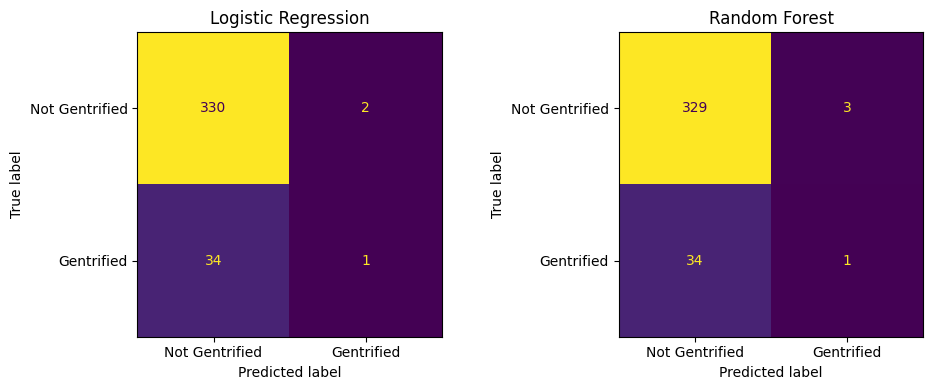

In [133]:


rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42069))
])

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

rf_params = {
    'rf__n_estimators': [50, 100, 150, 200, 250],
    'rf__max_depth': [3, 5, 7, 9],
    'rf__max_features': np.arange(0.1, 1, 0.1)
}

def lr_rf_compare_cv(X, y, groups, groupKFolds= GroupKFold(n_splits=3)): 
    results = []

    # acculumate all predictions across the folds for the overall confusion matrix
    all_preds = {'logistic regression': {'y_obs': [], 'y_pred':[]},
                 'random forest': {'y_obs':[], 'y_pred':[]}}
    

    for fold, (train_idx, test_idx) in enumerate(groupKFolds.split(X, y, groups=groups)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # logistic regression
        lr = clone(lr_pipe)
        lr.fit(X_train, y_train)

        # random forest hyperparameter turning (tune on training fold only)
        rf_search = RandomizedSearchCV(
            clone(rf_pipe),
            param_distributions=rf_params,
            scoring="f1",
            random_state=42069
        )

        rf_search.fit(X_train, y_train)
        best_rf = rf_search.best_estimator_
        print(f"Fold {fold+1} best RF params: {rf_search.best_params_}")

        for name, model in (('logistic regression', lr), ('random forest', best_rf)):
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

            all_preds[name]['y_obs'].extend(y_test)
            all_preds[name]['y_pred'].extend(y_pred)

            results.append({
                'model': name,
                'fold': fold + 1,
                'accuracy': accuracy_score(y_test, y_pred),
                'roc_auc': roc_auc_score(y_test, y_proba),
                "f1": f1_score(y_test, y_pred)
            })
    # overall confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (name, preds) in zip(axes, all_preds.items()):
        cm = confusion_matrix(preds['y_obs'], preds['y_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Not Gentrified', 'Gentrified'])
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(name.title())
    plt.tight_layout()
    plt.show()
    return results


results_10 = lr_rf_compare_cv(X, y, groups)






In [134]:
results_df_10 = pd.DataFrame(results_10)
results_summary_10 = (results_df_10.groupby('model')[['accuracy', 'roc_auc', 'f1']]
             .agg(['mean', 'std']))
print(results_summary_10)

                     accuracy             roc_auc                  f1  \
                         mean       std      mean       std      mean   
model                                                                   
logistic regression  0.901928  0.007768  0.596439  0.075639  0.047619   
random forest        0.899174  0.020686  0.730701  0.038812  0.039216   

                               
                          std  
model                          
logistic regression  0.082479  
random forest        0.067924  


In [135]:
results_df_10

,model,fold,accuracy,roc_auc,f1
0,logistic regression,1,0.894309,0.662162,0.000000
1,random forest,1,0.902439,0.755255,0.000000
2,logistic regression,2,0.901639,0.513761,0.142857
3,random forest,2,0.877049,0.685956,0.117647
4,logistic regression,3,0.909836,0.613393,0.000000
5,random forest,3,0.918033,0.750893,0.000000


### Post-2020 reports

Fold 1 best RF params: {'rf__n_estimators': 250, 'rf__max_features': np.float64(0.1), 'rf__max_depth': 7}
Fold 2 best RF params: {'rf__n_estimators': 200, 'rf__max_features': np.float64(0.7000000000000001), 'rf__max_depth': 9}
Fold 3 best RF params: {'rf__n_estimators': 200, 'rf__max_features': np.float64(0.7000000000000001), 'rf__max_depth': 9}


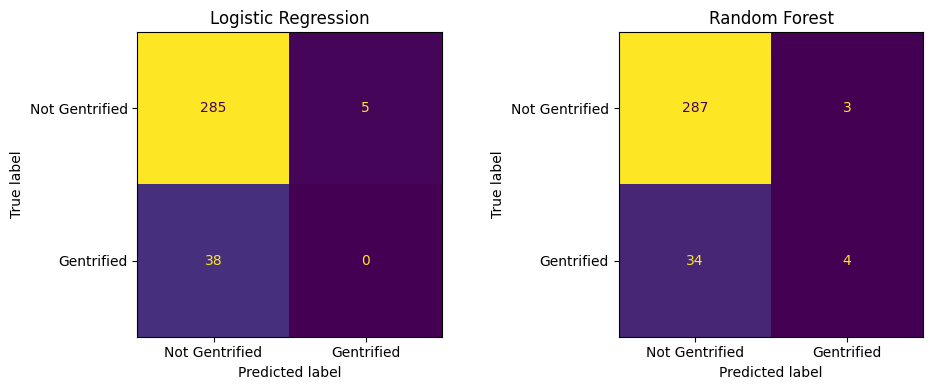

In [136]:
X = tract_neigh_20[['mean_brew_reviews', 'brewery_prop_slope', 'prop_black', 'prop_asian', 'prop_hispanic_or_latino', 'med_prop_val', 'med_inc', 'pct_bachelor_or_higher']]
y = tract_neigh_20['gentrified']

groups =tract_neigh_20["neighborhood"]

results_20 = lr_rf_compare_cv(X, y, groups)


In [137]:
results_df_20 = pd.DataFrame(results_20)
results_summary_20 = (results_df_20.groupby('model')[['accuracy', 'roc_auc', 'f1']]
             .agg(['mean', 'std']))
print(results_summary_20)

                     accuracy             roc_auc                  f1  \
                         mean       std      mean       std      mean   
model                                                                   
logistic regression  0.868919  0.036981  0.546159  0.014758  0.000000   
random forest        0.887212  0.027916  0.800944  0.031762  0.175226   

                               
                          std  
model                          
logistic regression  0.000000  
random forest        0.039016  
